bert_02_attention_backward.py
=============================
Stage 2 of the BERT-style masked attention walkthrough.

Loads bert_embeddings.pt and runs:

    x  (T, d_model)
      → W_Q, W_K, W_V projections   (manual Linear, no bias)
      → split into H heads
      → F.scaled_dot_product_attention  (NO causal mask — bidirectional)
      → concat heads  → W_O projection
      → MLM head: LayerNorm → Linear → GELU → Linear → unembed
      → cross-entropy loss ONLY at [MASK] positions
      → loss.backward()
      → print gradient summary
      → save figures:
            bert_02_attention.png  — full bidirectional attention heatmaps
            bert_02_grads.png      — grad norms + projection grad heatmaps

Key differences from the causal (GPT) version
----------------------------------------------
  Attention  : no causal mask → every token attends to every token
  Loss       : computed only at [MASK] positions, not all positions
  MLM head   : small MLP on top of attention output before unembedding
  Task       : predict the original token at each [MASK] position

In [1]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention/bert"

/content/drive/MyDrive/Courses/AI/masked_attention/bert


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [3]:
# ── 0. Load ───────────────────────────────────────────────────────────────────

data           = torch.load("bert_embeddings.pt", weights_only=True)
x_base         = data["x"]               # (T, d_model)
tokens         = data["tokens"]           # list[str]  — original with [CLS]/[SEP]
masked_tokens  = data["masked_tokens"]    # list[str]  — with [MASK] substituted
original_ids   = data["original_ids"]     # (T,)  ground truth
mask_positions = data["mask_positions"]   # list[int]  positions where loss is computed
T              = data["T"]
D_MODEL        = data["D_MODEL"]
VOCAB_SIZE     = data["VOCAB_SIZE"]
emb_weight     = data["emb_weight"]       # (vocab, d_model)
SENTENCE       = data["SENTENCE"]

print("=" * 60)
print("Loaded from bert_embeddings.pt")
print("=" * 60)
print(f"  Sentence       : '{SENTENCE}'")
print(f"  Tokens         : {masked_tokens}")
print(f"  Mask positions : {mask_positions}  {[masked_tokens[p] for p in mask_positions]}")
print(f"  Targets        : {[original_ids[p].item() for p in mask_positions]}"
      f"  {[tokens[p] for p in mask_positions]}")

Loaded from bert_embeddings.pt
  Sentence       : 'the cat sat on the mat'
  Tokens         : ['[CLS]', 'the', '[MASK]', 'sat', 'on', 'the', '[MASK]', '[SEP]']
  Mask positions : [2, 6]  ['[MASK]', '[MASK]']
  Targets        : [4937, 13523]  ['cat', 'mat']


In [4]:
# ── 1. Hyperparameters ────────────────────────────────────────────────────────

N_HEADS = 4
D_HEAD  = D_MODEL // N_HEADS

print(f"\n  N_HEADS={N_HEADS}  D_HEAD={D_HEAD}  D_MODEL={D_MODEL}")

# ── 2. Projection matrices ────────────────────────────────────────────────────

torch.manual_seed(42)

W_Q = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_K = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_V = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_O = nn.Linear(D_MODEL, D_MODEL, bias=False)

x = x_base.clone().requires_grad_(True)
x.retain_grad()   # x is non-leaf after .clone(); retain_grad() keeps .grad populated

print("\n" + "=" * 60)
print("STEP 1 — PROJECTION MATRICES")
print("=" * 60)
print(f"  W_Q : {W_Q.weight.shape}")
print(f"  W_K : {W_K.weight.shape}")
print(f"  W_V : {W_V.weight.shape}")
print(f"  W_O : {W_O.weight.shape}")


  N_HEADS=4  D_HEAD=16  D_MODEL=64

STEP 1 — PROJECTION MATRICES
  W_Q : torch.Size([64, 64])
  W_K : torch.Size([64, 64])
  W_V : torch.Size([64, 64])
  W_O : torch.Size([64, 64])


In [5]:
# ── 3. Q, K, V ───────────────────────────────────────────────────────────────

Q = W_Q(x)   # (T, d_model)
K = W_K(x)   # (T, d_model)
V = W_V(x)   # (T, d_model)

print("\n" + "=" * 60)
print("STEP 2 — Q, K, V PROJECTIONS")
print("=" * 60)
print(f"  Q : {Q.shape}")
print(f"  K : {K.shape}")
print(f"  V : {V.shape}")


STEP 2 — Q, K, V PROJECTIONS
  Q : torch.Size([8, 64])
  K : torch.Size([8, 64])
  V : torch.Size([8, 64])


In [6]:
# ── 4. Split into heads ───────────────────────────────────────────────────────

def split_heads(z: torch.Tensor) -> torch.Tensor:
    """(T, d_model) → (N_HEADS, T, D_HEAD)"""
    T_, d = z.shape
    return z.view(T_, N_HEADS, D_HEAD).permute(1, 0, 2)

Q_h = split_heads(Q)   # (N_HEADS, T, D_HEAD)
K_h = split_heads(K)
V_h = split_heads(V)

print("\n" + "=" * 60)
print("STEP 3 — SPLIT INTO HEADS")
print("=" * 60)
print(f"  Q_h : {Q_h.shape}  (N_HEADS, T, D_HEAD)")


STEP 3 — SPLIT INTO HEADS
  Q_h : torch.Size([4, 8, 16])  (N_HEADS, T, D_HEAD)


In [7]:
# ── 5. No causal mask — full bidirectional attention ─────────────────────────
#
# GPT used: causal_mask = torch.tril(...)  → lower triangle only
#
# BERT uses NO mask. Every token can attend to every other token in both
# directions. [MASK] tokens can attend to real tokens and vice versa —
# that is exactly how BERT "fills in" the masked positions.
#
# F.sdpa with attn_mask=None defaults to full attention (all positions visible).

attn_out = F.scaled_dot_product_attention(
    Q_h, K_h, V_h,
    attn_mask=None,     # ← no mask: full bidirectional attention
    dropout_p=0.0,
    scale=D_HEAD ** -0.5,
)
# attn_out : (N_HEADS, T, D_HEAD)

print("\n" + "=" * 60)
print("STEP 4 — BIDIRECTIONAL ATTENTION  (no causal mask)")
print("=" * 60)
print(f"  attn_mask = None  → every token attends to every token")
print(f"  attn_out  : {attn_out.shape}")

# Recompute attention weights manually for visualisation (F.sdpa fuses ops)
with torch.no_grad():
    scores = (Q_h @ K_h.transpose(-2, -1)) * (D_HEAD ** -0.5)   # (H, T, T)
    # no masked_fill here — all positions are valid
    attn_w = scores.softmax(dim=-1)    # (H, T, T)

print(f"\n  attn_w (for viz) : {attn_w.shape}")
print(f"\n  Head 0 — full attention matrix:")
header = "            " + " ".join(f"{tok:>7}" for tok in masked_tokens)
print(header)
for i, tok in enumerate(masked_tokens):
    row = " ".join(f"{attn_w[0, i, j].item():7.3f}" for j in range(T))
    print(f"  {tok:>8}   {row}")



STEP 4 — BIDIRECTIONAL ATTENTION  (no causal mask)
  attn_mask = None  → every token attends to every token
  attn_out  : torch.Size([4, 8, 16])

  attn_w (for viz) : torch.Size([4, 8, 8])

  Head 0 — full attention matrix:
              [CLS]     the  [MASK]     sat      on     the  [MASK]   [SEP]
     [CLS]     0.110   0.066   0.091   0.117   0.144   0.230   0.148   0.095
       the     0.094   0.062   0.446   0.116   0.176   0.072   0.014   0.020
    [MASK]     0.102   0.041   0.242   0.034   0.314   0.190   0.042   0.037
       sat     0.209   0.031   0.109   0.078   0.194   0.228   0.069   0.083
        on     0.061   0.035   0.326   0.372   0.103   0.041   0.053   0.009
       the     0.121   0.050   0.275   0.154   0.202   0.111   0.033   0.053
    [MASK]     0.116   0.088   0.136   0.068   0.242   0.277   0.039   0.034
     [SEP]     0.062   0.101   0.460   0.022   0.206   0.087   0.043   0.017


In [8]:
# ── 6. Concat heads + W_O ────────────────────────────────────────────────────

def concat_heads(z: torch.Tensor) -> torch.Tensor:
    """(N_HEADS, T, D_HEAD) → (T, d_model)"""
    H, T_, d_h = z.shape
    return z.permute(1, 0, 2).contiguous().view(T_, H * d_h)

attn_concat = concat_heads(attn_out)   # (T, d_model)
attn_proj   = W_O(attn_concat)        # (T, d_model)

print("\n" + "=" * 60)
print("STEP 5 — CONCAT HEADS + W_O")
print("=" * 60)
print(f"  attn_out    : {attn_out.shape}  (H, T, D_HEAD)")
print(f"  attn_concat : {attn_concat.shape}  after concat")
print(f"  attn_proj   : {attn_proj.shape}  after W_O")


STEP 5 — CONCAT HEADS + W_O
  attn_out    : torch.Size([4, 8, 16])  (H, T, D_HEAD)
  attn_concat : torch.Size([8, 64])  after concat
  attn_proj   : torch.Size([8, 64])  after W_O


In [9]:
# ── 7. MLM head ───────────────────────────────────────────────────────────────
#
# Real BERT inserts a small MLP between attention output and the final
# vocabulary projection:
#
#   attn_proj → LayerNorm → Linear(d_model, d_model) → GELU → unembed
#
# This lets the model transform the contextualised representation before
# projecting to vocabulary size. We keep it small but structurally correct.

mlm_norm    = nn.LayerNorm(D_MODEL)
mlm_dense   = nn.Linear(D_MODEL, D_MODEL)   # transform before unembedding

mlm_hidden  = F.gelu(mlm_dense(mlm_norm(attn_proj)))   # (T, d_model)
logits      = mlm_hidden @ emb_weight.T                 # (T, vocab_size)  weight-tied unembed

print("\n" + "=" * 60)
print("STEP 6 — MLM HEAD")
print("=" * 60)
print(f"  LayerNorm → Linear({D_MODEL},{D_MODEL}) → GELU → unembed")
print(f"  mlm_hidden : {mlm_hidden.shape}")
print(f"  logits     : {logits.shape}  (T, vocab_size)")



STEP 6 — MLM HEAD
  LayerNorm → Linear(64,64) → GELU → unembed
  mlm_hidden : torch.Size([8, 64])
  logits     : torch.Size([8, 30522])  (T, vocab_size)


In [10]:
# ── 8. Loss — only at [MASK] positions ───────────────────────────────────────
#
# GPT computed loss at every position: logits[:-1] vs ids[1:]
#
# BERT computes loss ONLY where the input was [MASK].
# Everything else is ignored — the model is not penalised for its output
# at non-masked positions.

mask_pos_tensor = torch.tensor(mask_positions)                # (n_masked,)
pred_at_masks   = logits[mask_pos_tensor]                     # (n_masked, vocab)
true_at_masks   = original_ids[mask_pos_tensor]               # (n_masked,)

loss = F.cross_entropy(pred_at_masks, true_at_masks)

print("\n" + "=" * 60)
print("STEP 7 — MLM LOSS  (only at [MASK] positions)")
print("=" * 60)
print(f"  mask_positions  : {mask_positions}")
print(f"  pred_at_masks   : {pred_at_masks.shape}  logits[mask_positions]")
print(f"  true_at_masks   : {true_at_masks.tolist()}  original token ids")
print(f"  loss            : {loss.item():.6f}")
print(f"\n  Per-mask cross-entropy:")
for pos, true_id in zip(mask_positions, true_at_masks.tolist()):
    ce = F.cross_entropy(
        logits[pos].unsqueeze(0),
        torch.tensor([true_id])
    )
    true_tok = tokens[pos]
    top1_id  = logits[pos].argmax().item()
    print(f"    pos {pos}  target='{true_tok}' (id={true_id})  CE={ce.item():.4f}"
          f"  top1_pred_id={top1_id}")


STEP 7 — MLM LOSS  (only at [MASK] positions)
  mask_positions  : [2, 6]
  pred_at_masks   : torch.Size([2, 30522])  logits[mask_positions]
  true_at_masks   : [4937, 13523]  original token ids
  loss            : 15.759106

  Per-mask cross-entropy:
    pos 2  target='cat' (id=4937)  CE=14.9529  top1_pred_id=23037
    pos 6  target='mat' (id=13523)  CE=16.5654  top1_pred_id=26760


In [11]:
# ── 9. Backward ───────────────────────────────────────────────────────────────

loss.backward()

print("\n" + "=" * 60)
print("STEP 8 — BACKWARD PASS")
print("=" * 60)

params = {
    "x":              x,
    "W_Q.weight":     W_Q.weight,
    "W_K.weight":     W_K.weight,
    "W_V.weight":     W_V.weight,
    "W_O.weight":     W_O.weight,
    "mlm_dense.weight": mlm_dense.weight,
}

print(f"\n  {'Parameter':<22}  {'shape':<22}  {'L2 norm':>12}  {'max |grad|':>12}")
print("  " + "-" * 72)
for name, p in params.items():
    g = p.grad
    if g is None:
        print(f"  {name:<22}  {'—':22}")
    else:
        print(f"  {name:<22}  {str(g.shape):<22}  {g.norm().item():>12.6f}"
              f"  {g.abs().max().item():>12.6f}")

# Gradient at x per token position — shows which tokens received signal
print(f"\n  x.grad per token position (L2 norm of each row):")
print(f"  {'token':>10}  {'masked?':>8}  {'||grad||':>10}")
for i, tok in enumerate(masked_tokens):
    is_masked = "← MASK" if i in mask_positions else ""
    print(f"  {tok:>10}  {is_masked:>8}  {x.grad[i].norm().item():>10.6f}")

print("""
  Note: in bidirectional attention every token's gradient depends on every
  other token — including the [MASK] positions. The gradient at a non-masked
  token is non-zero because that token's representation was used (via K and V)
  to compute the output at the [MASK] positions.
""")


STEP 8 — BACKWARD PASS

  Parameter               shape                        L2 norm    max |grad|
  ------------------------------------------------------------------------
  x                       torch.Size([8, 64])         1.586173      0.283677
  W_Q.weight              torch.Size([64, 64])       13.475527      1.406155
  W_K.weight              torch.Size([64, 64])       14.297157      1.767552
  W_V.weight              torch.Size([64, 64])       40.509586      3.555533
  W_O.weight              torch.Size([64, 64])       35.986519      3.040893
  mlm_dense.weight        torch.Size([64, 64])       36.045006      4.888177

  x.grad per token position (L2 norm of each row):
       token   masked?    ||grad||
       [CLS]              0.330044
         the              0.330641
      [MASK]    ← MASK    0.832270
         sat              0.683863
          on              0.595544
         the              0.494533
      [MASK]    ← MASK    0.661931
       [SEP]              0.3

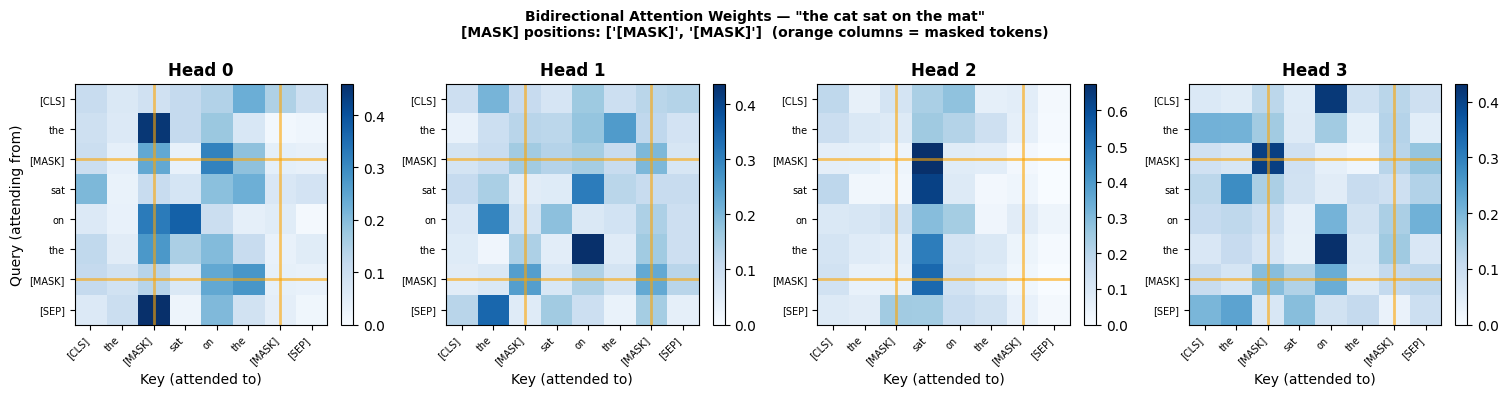

  Figure saved → 'bert_02_attention.png'


/tmp/ipykernel_31912/45651512.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(pnames, rotation=20, ha="right", fontsize=8)


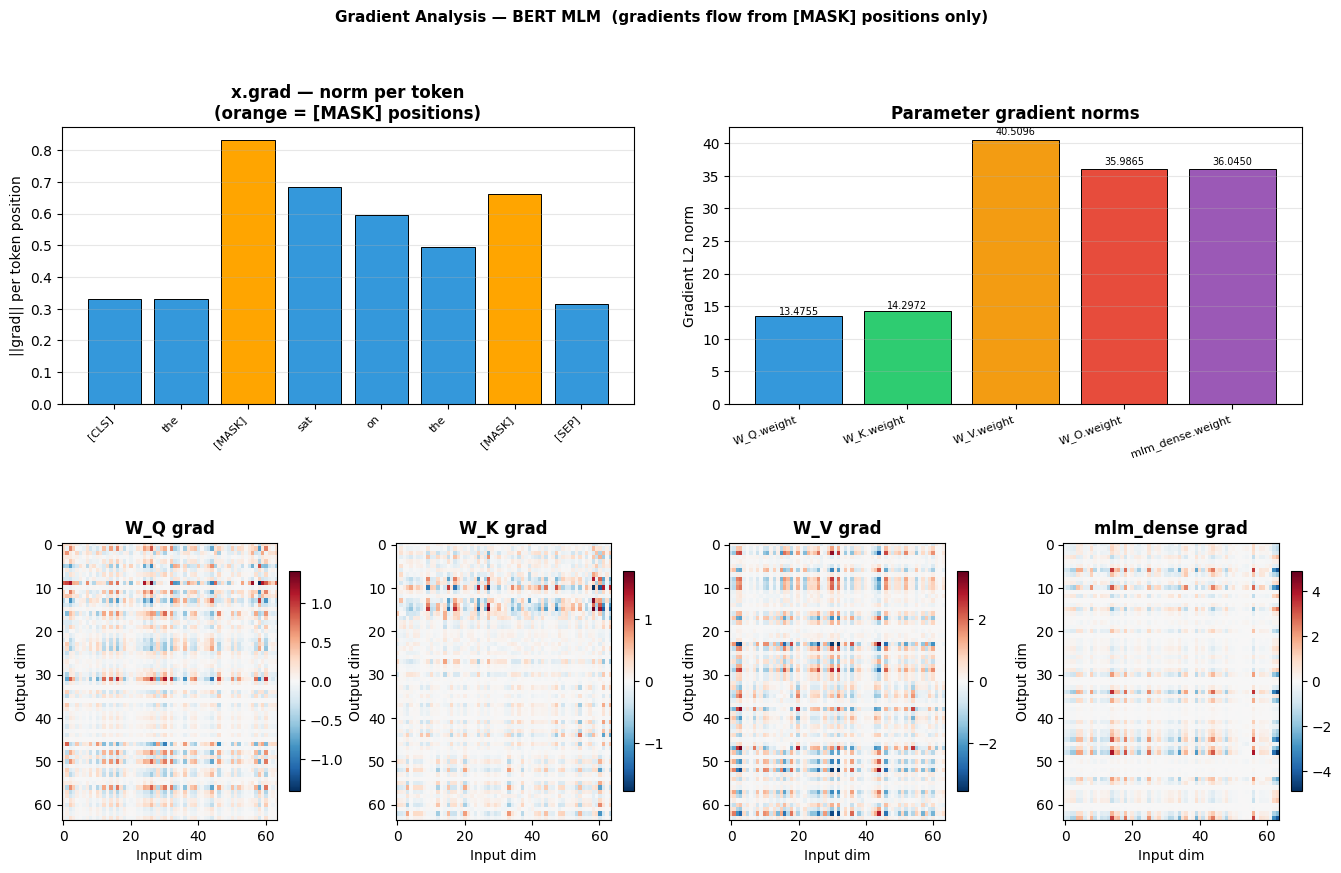

  Figure saved → 'bert_02_grads.png'


In [12]:
# ── 10. Figures ───────────────────────────────────────────────────────────────

# Figure A — attention heatmaps per head
fig_a, axes_a = plt.subplots(1, N_HEADS, figsize=(3.8 * N_HEADS, 4))
fig_a.suptitle(
    f'Bidirectional Attention Weights — "{SENTENCE}"\n'
    f'[MASK] positions: {[masked_tokens[p] for p in mask_positions]}  '
    f'(orange columns = masked tokens)',
    fontsize=10, fontweight="bold"
)

for h in range(N_HEADS):
    ax = axes_a[h]
    w  = attn_w[h].detach().numpy()
    im = ax.imshow(w, vmin=0, vmax=w.max(), cmap="Blues", aspect="auto")
    ax.set_title(f"Head {h}", fontweight="bold")
    ax.set_xticks(range(T)); ax.set_xticklabels(masked_tokens, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(T)); ax.set_yticklabels(masked_tokens, fontsize=7)
    ax.set_xlabel("Key (attended to)")
    if h == 0:
        ax.set_ylabel("Query (attending from)")
    # highlight mask positions
    for pos in mask_positions:
        ax.axvline(pos, color="orange", lw=2, alpha=0.6)
        ax.axhline(pos, color="orange", lw=2, alpha=0.6)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("bert_02_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure saved → 'bert_02_attention.png'")

# Figure B — gradient analysis
fig_b = plt.figure(figsize=(16, 9))
gs    = gridspec.GridSpec(2, 4, figure=fig_b, hspace=0.5, wspace=0.4)

# (a) Grad norm per token position (x.grad row norms)
ax_tok = fig_b.add_subplot(gs[0, :2])
row_norms = x.grad.norm(dim=-1).detach().numpy()
bar_colors = ["orange" if i in mask_positions else "#3498db" for i in range(T)]
ax_tok.bar(range(T), row_norms, color=bar_colors, edgecolor="black", lw=0.7)
ax_tok.set_xticks(range(T))
ax_tok.set_xticklabels(masked_tokens, rotation=45, ha="right", fontsize=8)
ax_tok.set_ylabel("||grad|| per token position")
ax_tok.set_title("x.grad — norm per token\n(orange = [MASK] positions)", fontweight="bold")
ax_tok.grid(axis="y", alpha=0.3)

# (b) Grad L2 norms per parameter
ax_bar = fig_b.add_subplot(gs[0, 2:])
pnames = [n for n in params if n != "x"]
norms  = [params[n].grad.norm().item() for n in pnames]
colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]
bars   = ax_bar.bar(pnames, norms, color=colors, edgecolor="black", lw=0.7)
ax_bar.set_ylabel("Gradient L2 norm")
ax_bar.set_title("Parameter gradient norms", fontweight="bold")
ax_bar.set_xticklabels(pnames, rotation=20, ha="right", fontsize=8)
ax_bar.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, norms):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val*1.02,
                f"{val:.4f}", ha="center", fontsize=7)

# (c-e) W_Q, W_K, W_V gradient heatmaps
for col, (title, weight) in enumerate([
    ("W_Q grad", W_Q.weight),
    ("W_K grad", W_K.weight),
    ("W_V grad", W_V.weight),
]):
    ax  = fig_b.add_subplot(gs[1, col])
    g   = weight.grad.detach().numpy()
    vm  = np.abs(g).max()
    im  = ax.imshow(g, cmap="RdBu_r", vmin=-vm, vmax=vm, aspect="auto")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Input dim")
    ax.set_ylabel("Output dim")
    plt.colorbar(im, ax=ax, fraction=0.046)

# (f) MLM dense grad heatmap
ax_mlm = fig_b.add_subplot(gs[1, 3])
g   = mlm_dense.weight.grad.detach().numpy()
vm  = np.abs(g).max()
im  = ax_mlm.imshow(g, cmap="RdBu_r", vmin=-vm, vmax=vm, aspect="auto")
ax_mlm.set_title("mlm_dense grad", fontweight="bold")
ax_mlm.set_xlabel("Input dim")
ax_mlm.set_ylabel("Output dim")
plt.colorbar(im, ax=ax_mlm, fraction=0.046)

fig_b.suptitle(
    "Gradient Analysis — BERT MLM  (gradients flow from [MASK] positions only)",
    fontsize=11, fontweight="bold", y=1.01
)
plt.savefig("bert_02_grads.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure saved → 'bert_02_grads.png'")